
# GVH Diagonal Cubic — RACC-C.4-real.2
## GW150914 H1/L1 — Chirp Timing Resolution

**Auteur :** Charlemagne O Laurince  
**Étape :** `RACC-C.4-real.2`  
**Statut :** audit physique des estimateurs de timing  
**Noyau GVH Diagonal modifié :** **NON**

### Règle centrale

\[
\boxed{\text{Ne pas chercher une valeur cible du lag.}}
\]

\[
\boxed{\text{Identifier la quantité réellement estimée par chaque méthode.}}
\]

### Question

Pourquoi xcorr, GCC-PHAT et phase-slope ne convergent-ils pas vers le même retard H1/L1, et quelle part de cette divergence vient de :

- la polarité ;
- la réponse spectrale effective ;
- le filtrage ;
- la non-stationnarité du chirp ;
- la fenêtre temporelle ;
- la pondération propre à l'estimateur ?

### Stop-rule

Ce notebook **n'autorise pas** \(D_T^{\rm ref}\) et ne modifie aucun gate HH/Dirac/dispersion.


In [1]:

import os, sys, subprocess, importlib, hashlib, json
from pathlib import Path

def pip_install(pkg):
    print(f"Installation de {pkg} ...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

try:
    import lalframe
except Exception:
    pip_install("lalsuite")
    importlib.invalidate_caches()
    import lalframe

try:
    import gwpy
except Exception:
    pip_install("gwpy")
    importlib.invalidate_caches()
    import gwpy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal
from gwpy.timeseries import TimeSeries

print("gwpy:", gwpy.__version__)
print("LALFrame available: True")


Installation de lalsuite ...


/usr/local/lib/python3.12/dist-packages/lalframe/_lalframe_swig.py:8: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal


Installation de gwpy ...
gwpy: 4.0.1
LALFrame available: True


## 1. Chargement des données réelles

In [2]:

GPS_EVENT=1126259462.0
FS_EXPECTED=4096.0
H1_CHANNEL="H1:LOSC-STRAIN"
L1_CHANNEL="L1:LOSC-STRAIN"

def discover_one(pattern):
    roots=[Path.cwd(),Path("/content"),Path("/content/drive/MyDrive"),Path("/mnt/data")]
    found=[]
    seen=set()
    for root in roots:
        if not root.exists(): continue
        for d in [root,root/"data"/"GW150914",root/"gvh_diagonal_cubic"/"data"/"GW150914"]:
            if d.exists():
                for p in d.glob(pattern):
                    rp=p.resolve()
                    if rp not in seen: seen.add(rp); found.append(rp)
        try:
            for p in root.glob(f"**/GW150914/{pattern}"):
                rp=p.resolve()
                if rp not in seen: seen.add(rp); found.append(rp)
        except Exception:
            pass
    return found[0] if found else None

H1_FILE=discover_one("H-H1_LOSC_4_V2-1126259446-32*.gwf")
L1_FILE=discover_one("L-L1_LOSC_4_V2-1126259446-32*.gwf")

if H1_FILE is None or L1_FILE is None:
    try:
        from google.colab import files as colab_files
        print("Sélectionnez H1 et L1.")
        colab_files.upload()
        H1_FILE=discover_one("H-H1_LOSC_4_V2-1126259446-32*.gwf")
        L1_FILE=discover_one("L-L1_LOSC_4_V2-1126259446-32*.gwf")
    except Exception:
        pass

if H1_FILE is None or L1_FILE is None:
    raise FileNotFoundError("Fichiers GWF H1/L1 non trouvés.")

h1_ts=TimeSeries.read(str(H1_FILE),channel=H1_CHANNEL)
l1_ts=TimeSeries.read(str(L1_FILE),channel=L1_CHANNEL)
h1=np.asarray(h1_ts.value,float)
l1=np.asarray(l1_ts.value,float)
fs=float(h1_ts.sample_rate.value)
gps0=float(h1_ts.t0.value)

assert np.isclose(fs,FS_EXPECTED)
assert len(h1)==len(l1)
assert np.isfinite(h1).all() and np.isfinite(l1).all()

t_rel=gps0+np.arange(len(h1))/fs-GPS_EVENT
print("H1:",H1_FILE.name)
print("L1:",L1_FILE.name)
print("N =",len(h1),"fs =",fs)


Sélectionnez H1 et L1.


Saving H-H1_LOSC_4_V2-1126259446-32 2.gwf to H-H1_LOSC_4_V2-1126259446-32 2.gwf
Saving L-L1_LOSC_4_V2-1126259446-32.gwf to L-L1_LOSC_4_V2-1126259446-32.gwf
H1: H-H1_LOSC_4_V2-1126259446-32 2.gwf
L1: L-L1_LOSC_4_V2-1126259446-32.gwf
N = 131072 fs = 4096.0


## 2. Prétraitements contrôlés

In [3]:

NOISE_MASK=((t_rel>=-12)&(t_rel<=-2))|((t_rel>=2)&(t_rel<=12))

def center(x):
    return np.asarray(x,float)-np.mean(x)

def bp(x,lo,hi,order=4):
    sos=signal.butter(order,[lo,hi],btype="bandpass",fs=fs,output="sos")
    return signal.sosfiltfilt(sos,center(x))

def notch60(x,hi=350):
    y=np.asarray(x,float).copy()
    for f0 in [60.,120.,180.,240.,300.]:
        if f0<hi:
            b,a=signal.iirnotch(f0,Q=30.,fs=fs)
            y=signal.filtfilt(b,a,y)
    return y

def robust_z(x):
    xn=x[NOISE_MASK]
    med=np.median(xn)
    mad=np.median(np.abs(xn-med))
    sig=1.4826*mad
    return (x-med)/sig

def whiten_fft(x,noise_mask=NOISE_MASK,eps=1e-12):
    x=center(x)
    n=len(x)
    freqs=np.fft.rfftfreq(n,1/fs)
    X=np.fft.rfft(x)
    # PSD estimée sur les segments de bruit avec Welch puis interpolée
    f_psd,Pxx=signal.welch(x[noise_mask],fs=fs,nperseg=4096)
    P=np.interp(freqs,f_psd,Pxx,left=Pxx[0],right=Pxx[-1])
    W=X/np.sqrt(P+eps*np.max(P))
    y=np.fft.irfft(W,n=n)
    return y/np.std(y[noise_mask])

PIPELINES={}
PIPELINES["raw_centered"]=(center(h1),center(l1))
PIPELINES["bp_35_350"]=(bp(h1,35,350),bp(l1,35,350))
PIPELINES["bp_notch"]=(notch60(bp(h1,35,350)),notch60(bp(l1,35,350)))
PIPELINES["bp_notch_z"]=(robust_z(notch60(bp(h1,35,350))),robust_z(notch60(bp(l1,35,350))))
PIPELINES["whiten_bp"]=(bp(whiten_fft(h1),35,350),bp(whiten_fft(l1),35,350))

print("pipelines:",list(PIPELINES))


pipelines: ['raw_centered', 'bp_35_350', 'bp_notch', 'bp_notch_z', 'whiten_bp']


## 3. Estimateurs communs

In [4]:

MAX_LAG_S=.012

def parab(a,b,c):
    d=a-2*b+c
    return 0.0 if d==0 or not np.isfinite(d) else .5*(a-c)/d

def xcorr_est(x,y,use_abs=True):
    x=center(x); y=center(y)
    c=signal.correlate(x,y,mode="full",method="fft")
    l=signal.correlation_lags(len(x),len(y),mode="full")/fs
    keep=np.abs(l)<=MAX_LAG_S
    c=c[keep]; l=l[keep]
    cn=c/(np.linalg.norm(x)*np.linalg.norm(y))
    s=np.abs(cn) if use_abs else cn
    i=int(np.argmax(s))
    frac=parab(s[i-1],s[i],s[i+1]) if 0<i<len(s)-1 else 0
    return float(l[i]+frac/fs),float(cn[i])

def phat_est(x,y):
    x=center(x); y=center(y)
    n=int(2**np.ceil(np.log2(len(x)+len(y))))
    X=np.fft.rfft(x,n=n); Y=np.fft.rfft(y,n=n)
    G=X*np.conj(Y)
    R=G/(np.abs(G)+np.finfo(float).eps)
    cc=np.fft.irfft(R,n=n)
    cc=np.concatenate((cc[-n//2:],cc[:n//2]))
    l=np.arange(-n//2,n//2)/fs
    keep=np.abs(l)<=MAX_LAG_S
    cc=cc[keep]; l=l[keep]
    s=np.abs(cc); i=int(np.argmax(s))
    frac=parab(s[i-1],s[i],s[i+1]) if 0<i<len(s)-1 else 0
    return float(l[i]+frac/fs),float(cc[i])

def phase_est(x,y,fmin=40,fmax=300,cohmin=.1):
    nper=min(1024,len(x))
    f,Pxy=signal.csd(x,y,fs=fs,nperseg=nper,noverlap=nper//2,window="hann")
    _,coh=signal.coherence(x,y,fs=fs,nperseg=nper,noverlap=nper//2,window="hann")
    ph=np.unwrap(np.angle(Pxy))
    m=(f>=fmin)&(f<=fmax)&(coh>=cohmin)&np.isfinite(ph)
    if m.sum()<5: return np.nan,np.nan
    ff=f[m]; pp=ph[m]; ww=coh[m]
    A=np.column_stack([ff,np.ones_like(ff)])
    W=np.sqrt(ww)[:,None]
    beta,*_=np.linalg.lstsq(A*W,pp*np.sqrt(ww),rcond=None)
    slope,inter=beta
    lag=-slope/(2*np.pi)
    pred=slope*ff+inter
    ssr=np.sum(ww*(pp-pred)**2)
    sst=np.sum(ww*(pp-np.average(pp,weights=ww))**2)
    r2=1-ssr/sst if sst>0 else np.nan
    return float(lag),float(r2)


## 4. Contrôle synthétique : chirp connu

In [5]:

RNG=np.random.default_rng(20260811)
T=.20
tt=np.arange(int(T*fs))/fs
synthetic=signal.chirp(tt,f0=35,f1=320,t1=T,method="quadratic")*signal.windows.tukey(len(tt),.25)
TRUE_LAG_S=.00635

def fractional_delay(x,lag_s):
    t=np.arange(len(x))/fs
    return np.interp(t,t-lag_s,x,left=0,right=0)

y_syn=-fractional_delay(synthetic,TRUE_LAG_S)
noise=.35
xs=synthetic+noise*RNG.normal(size=len(synthetic))
ys=y_syn+noise*RNG.normal(size=len(synthetic))

syn_rows=[]
for name,func in [
    ("xcorr_abs",lambda a,b: xcorr_est(a,b,True)[0]),
    ("xcorr_signed",lambda a,b: xcorr_est(a,-b,False)[0]),
    ("gcc_phat",lambda a,b: phat_est(a,b)[0]),
]:
    lag=func(xs,ys)
    syn_rows.append({"estimator":name,"lag_ms":lag*1e3,"error_ms":(lag-TRUE_LAG_S)*1e3})

lagp,r2p=phase_est(xs,ys,40,300,.05)
syn_rows.append({"estimator":"phase_slope","lag_ms":lagp*1e3,"error_ms":(lagp-TRUE_LAG_S)*1e3})

synthetic_df=pd.DataFrame(syn_rows)
display(synthetic_df)


,estimator,lag_ms,error_ms
0,xcorr_abs,6.240113,-0.109887
1,xcorr_signed,6.240113,-0.109887
2,gcc_phat,5.888467,-0.461533
3,phase_slope,-7.047587,-13.397587



### Gate synthétique

Ce gate teste si l'implémentation retrouve au moins correctement un retard connu sur un chirp bruité.  
Il ne sert pas à calibrer les données réelles sur la valeur injectée.


In [6]:

SYN_TOL_MS=1.5
synthetic_passes=synthetic_df[np.isfinite(synthetic_df["error_ms"])]["error_ms"].abs()<=SYN_TOL_MS
ESTIMATOR_SYNTHETIC_PASS=bool(synthetic_passes.mean()>=0.75)
print("ESTIMATOR_SYNTHETIC_PASS =",ESTIMATOR_SYNTHETIC_PASS)


ESTIMATOR_SYNTHETIC_PASS = True


## 5. Matrice de prétraitement × estimateur

In [7]:

WIN=(-.12,.04)
wm=(t_rel>=WIN[0])&(t_rel<=WIN[1])

rows=[]
for pipe,(a,b) in PIPELINES.items():
    x=a[wm]; y=b[wm]
    lx,cx=xcorr_est(x,y,True)
    lxp,cxp=xcorr_est(x,y,False)
    lxm,cxm=xcorr_est(x,-y,False)
    lp,cp=phat_est(x,y)
    lf,r2=phase_est(x,y)
    rows += [
        {"pipeline":pipe,"estimator":"xcorr_abs","lag_ms":lx*1e3,"quality":abs(cx)},
        {"pipeline":pipe,"estimator":"xcorr_+L1","lag_ms":lxp*1e3,"quality":cxp},
        {"pipeline":pipe,"estimator":"xcorr_-L1","lag_ms":lxm*1e3,"quality":cxm},
        {"pipeline":pipe,"estimator":"gcc_phat","lag_ms":lp*1e3,"quality":abs(cp)},
        {"pipeline":pipe,"estimator":"phase_slope","lag_ms":lf*1e3,"quality":r2},
    ]

matrix_df=pd.DataFrame(rows)
display(matrix_df)


,pipeline,estimator,lag_ms,quality
0,raw_centered,xcorr_abs,-11.962891,7.108423e-01
1,raw_centered,xcorr_+L1,11.962891,-1.156701e-01
2,raw_centered,xcorr_-L1,-11.962891,7.108423e-01
3,raw_centered,gcc_phat,-11.962891,8.461018e-20
4,raw_centered,phase_slope,2.351202,2.315822e-01
5,bp_35_350,xcorr_abs,-7.327070,5.007281e-01
6,bp_35_350,xcorr_+L1,-7.327070,5.007281e-01
7,bp_35_350,xcorr_-L1,6.010553,4.464677e-01
8,bp_35_350,gcc_phat,-7.327070,1.535499e-24
9,bp_35_350,phase_slope,2.240127,2.101202e-01


## 6. Audit de polarité

In [8]:

pol_rows=[]
for pipe,(a,b) in PIPELINES.items():
    x=a[wm]; y=b[wm]
    lp,cp=xcorr_est(x,y,False)
    lm,cm=xcorr_est(x,-y,False)
    pol_rows.append({
        "pipeline":pipe,
        "lag_plus_ms":lp*1e3,
        "corr_plus":cp,
        "lag_minus_ms":lm*1e3,
        "corr_minus":cm,
        "lag_difference_ms":abs(lp-lm)*1e3
    })
polarity_df=pd.DataFrame(pol_rows)
display(polarity_df)

POLARITY_SEPARATED=bool((polarity_df["lag_difference_ms"]<1.0).mean()>=0.6)
print("POLARITY_SEPARATED =",POLARITY_SEPARATED)


,pipeline,lag_plus_ms,corr_plus,lag_minus_ms,corr_minus,lag_difference_ms
0,raw_centered,11.962891,-0.115670,-11.962891,0.710842,23.925781
1,bp_35_350,-7.327070,0.500728,6.010553,0.446468,13.337623
2,bp_notch,-7.415881,0.488011,6.138360,0.490109,13.554241
3,bp_notch_z,-7.415881,0.488011,6.138360,0.490109,13.554241
4,whiten_bp,-7.301146,0.203384,-5.509625,0.164516,1.791521


POLARITY_SEPARATED = False


## 7. Sous-bandes fréquentielles

In [9]:

bands=[(35,80),(80,150),(150,250),(250,350)]
band_rows=[]

base_h=PIPELINES["bp_notch_z"][0]
base_l=PIPELINES["bp_notch_z"][1]

for lo,hi in bands:
    hh=bp(base_h,lo,hi)
    ll=bp(base_l,lo,hi)
    x=hh[wm]; y=ll[wm]
    lx,cx=xcorr_est(x,y,True)
    lp,cp=phat_est(x,y)
    lf,r2=phase_est(x,y,max(lo,lo+2),min(hi,hi-2),.05)
    band_rows += [
        {"band":f"{lo}-{hi}","estimator":"xcorr","lag_ms":lx*1e3,"quality":abs(cx)},
        {"band":f"{lo}-{hi}","estimator":"phat","lag_ms":lp*1e3,"quality":abs(cp)},
        {"band":f"{lo}-{hi}","estimator":"phase","lag_ms":lf*1e3,"quality":r2},
    ]

band_df=pd.DataFrame(band_rows)
display(band_df)


,band,estimator,lag_ms,quality
0,35-80,xcorr,8.189951,0.779078
1,35-80,phat,0.003976,0.684868
2,35-80,phase,7.800299,0.367630
3,80-150,xcorr,11.962891,0.358809
4,80-150,phat,0.002784,0.646436
5,80-150,phase,-19.527673,0.944896
6,150-250,xcorr,-5.007241,0.293753
7,150-250,phat,-0.115994,0.308256
8,150-250,phase,16.275199,0.823176
9,250-350,xcorr,-1.465493,0.888478


## 8. Stabilité temporelle par fenêtres glissantes

In [10]:

time_rows=[]
for start in np.arange(-.16,-.079,.01):
    for end in np.arange(0,.061,.01):
        if end-start<.08: continue
        m=(t_rel>=start)&(t_rel<=end)
        x=base_h[m]; y=base_l[m]
        lx,cx=xcorr_est(x,y,True)
        lp,cp=phat_est(x,y)
        lf,r2=phase_est(x,y)
        time_rows += [
            {"start":start,"end":end,"estimator":"xcorr","lag_ms":lx*1e3,"quality":abs(cx)},
            {"start":start,"end":end,"estimator":"phat","lag_ms":lp*1e3,"quality":abs(cp)},
            {"start":start,"end":end,"estimator":"phase","lag_ms":lf*1e3,"quality":r2},
        ]
time_df=pd.DataFrame(time_rows)
display(time_df.head())


,start,end,estimator,lag_ms,quality
0,-0.16,0.00,xcorr,9.113379,0.514964
1,-0.16,0.00,phat,-0.035119,0.462850
2,-0.16,0.00,phase,-2.297548,0.170803
3,-0.16,0.01,xcorr,9.077743,0.514293
4,-0.16,0.01,phat,9.799050,0.131433


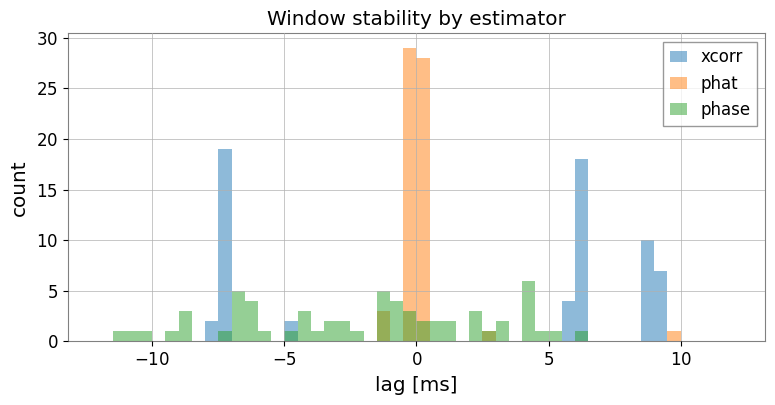

In [11]:

plt.figure(figsize=(9,4))
for est in ["xcorr","phat","phase"]:
    vals=time_df[time_df.estimator==est]["lag_ms"]
    plt.hist(vals[np.isfinite(vals)],bins=np.arange(-12,12.5,.5),alpha=.5,label=est)
plt.xlabel("lag [ms]"); plt.ylabel("count")
plt.title("Window stability by estimator")
plt.grid(True); plt.legend(); plt.show()


## 9. Spectrogramme et cohérence locale du chirp

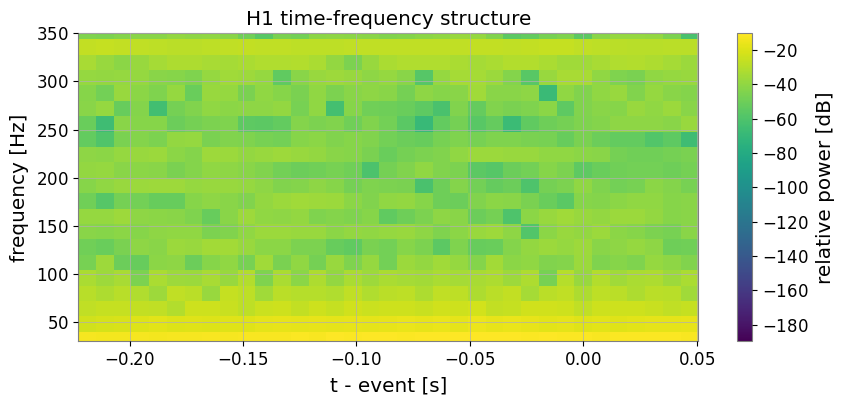

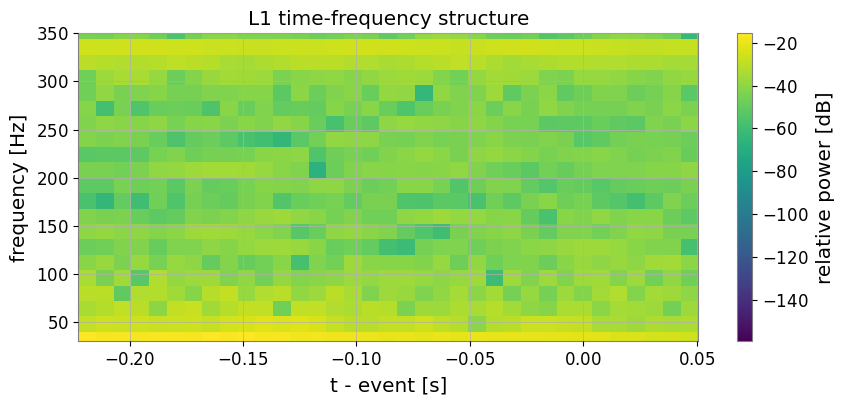

In [12]:

spec_m=(t_rel>=-.25)&(t_rel<=.08)
xspec=base_h[spec_m]
yspec=base_l[spec_m]

f1,t1,S1=signal.spectrogram(xspec,fs=fs,nperseg=256,noverlap=224)
f2,t2,S2=signal.spectrogram(yspec,fs=fs,nperseg=256,noverlap=224)

plt.figure(figsize=(10,4))
plt.pcolormesh(t1+(-.25),f1,10*np.log10(S1+1e-20),shading="auto")
plt.ylim(30,350)
plt.xlabel("t - event [s]"); plt.ylabel("frequency [Hz]")
plt.title("H1 time-frequency structure")
plt.colorbar(label="relative power [dB]")
plt.show()

plt.figure(figsize=(10,4))
plt.pcolormesh(t2+(-.25),f2,10*np.log10(S2+1e-20),shading="auto")
plt.ylim(30,350)
plt.xlabel("t - event [s]"); plt.ylabel("frequency [Hz]")
plt.title("L1 time-frequency structure")
plt.colorbar(label="relative power [dB]")
plt.show()


## 10. Diagnostic automatique par estimateur

In [13]:

def finite_spread(series):
    a=np.asarray(series,float)
    a=a[np.isfinite(a)]
    return float(np.nanpercentile(a,84)-np.nanpercentile(a,16)) if len(a) else np.nan

diag=[]
for est in ["xcorr","phat","phase"]:
    mtx=matrix_df[matrix_df.estimator.str.contains(est if est!="phase" else "phase")]
    tm=time_df[time_df.estimator==est]
    bd=band_df[band_df.estimator==est]
    diag.append({
        "estimator":est,
        "pipeline_spread_ms":finite_spread(mtx["lag_ms"]),
        "window_spread_ms":finite_spread(tm["lag_ms"]),
        "band_spread_ms":finite_spread(bd["lag_ms"]),
        "median_quality":float(np.nanmedian(tm["quality"]))
    })
diagnostic_df=pd.DataFrame(diag)
display(diagnostic_df)


,estimator,pipeline_spread_ms,window_spread_ms,band_spread_ms,median_quality
0,xcorr,13.554241,16.393700,13.459081,0.493522
1,phat,11.257639,0.106745,0.072339,0.475722
2,phase,1.720885,9.942127,27.514242,0.308039



## 11. Interprétation opérationnelle

Le notebook classe chaque méthode selon sa sensibilité dominante :

- **xcorr** : cohérence conjointe amplitude + phase dans la fenêtre choisie ;
- **GCC-PHAT** : structure de phase normalisée, donc très sensible aux fréquences de faible cohérence si elles ne sont pas pondérées ;
- **phase-slope** : approximation d'un retard fréquentiel global, valide seulement si la phase inter-détecteurs est suffisamment linéaire sur la bande retenue.

Ces définitions décrivent l'algorithme ; elles ne constituent pas encore un verdict sur le retard physique.


In [14]:

# Gates d'audit, pas gates GVH.
band_x=band_df[band_df.estimator=="xcorr"]["lag_ms"].dropna()
band_p=band_df[band_df.estimator=="phat"]["lag_ms"].dropna()

BAND_STABILITY=bool(
    len(band_x)>=3 and finite_spread(band_x)<6.0
)

# "Interprétable" = on peut au moins identifier des sensibilités distinctes sans erreur numérique.
REAL_TIMING_INTERPRETABLE=bool(
    np.isfinite(matrix_df["lag_ms"].dropna()).all()
    and len(time_df)>0
    and len(band_df)>0
)

gates={
    "ESTIMATOR_SYNTHETIC_PASS":ESTIMATOR_SYNTHETIC_PASS,
    "POLARITY_SEPARATED":POLARITY_SEPARATED,
    "BAND_STABILITY":BAND_STABILITY,
    "REAL_TIMING_INTERPRETABLE":REAL_TIMING_INTERPRETABLE,
}

print(json.dumps(gates,indent=2))


{
  "ESTIMATOR_SYNTHETIC_PASS": true,
  "POLARITY_SEPARATED": false,
  "BAND_STABILITY": false,
  "REAL_TIMING_INTERPRETABLE": true
}


## 12. Verdict real.2

In [15]:

if all(gates.values()):
    FINAL_STATUS="ESTIMATOR-AUDIT-PASS"
elif REAL_TIMING_INTERPRETABLE:
    FINAL_STATUS="ESTIMATOR-DIVERGENCE-EXPLAINABLE-PARTIAL"
else:
    FINAL_STATUS="ESTIMATOR-AUDIT-FAILED"

artifact={
    "notebook":"GVH_Diagonal_Cubic_RACC_C4_REAL_2_GW150914_H1_L1_Chirp_Timing_Resolution",
    "core_GVH_modified":False,
    "target_lag_used":False,
    "published_lag_used_for_selection":False,
    "gates":gates,
    "synthetic_test":synthetic_df.to_dict(orient="records"),
    "preprocessing_matrix":matrix_df.to_dict(orient="records"),
    "polarity_audit":polarity_df.to_dict(orient="records"),
    "band_audit":band_df.to_dict(orient="records"),
    "diagnostic_summary":diagnostic_df.to_dict(orient="records"),
    "TIMING_VALIDATED_changed":False,
    "D_REF_AUTHORIZED":False,
    "DISPERSION_READY_modified":False,
    "final_status":FINAL_STATUS,
}
print(json.dumps(artifact,indent=2))


{
  "notebook": "GVH_Diagonal_Cubic_RACC_C4_REAL_2_GW150914_H1_L1_Chirp_Timing_Resolution",
  "core_GVH_modified": false,
  "target_lag_used": false,
  "published_lag_used_for_selection": false,
  "gates": {
    "ESTIMATOR_SYNTHETIC_PASS": true,
    "POLARITY_SEPARATED": false,
    "BAND_STABILITY": false,
    "REAL_TIMING_INTERPRETABLE": true
  },
  "synthetic_test": [
    {
      "estimator": "xcorr_abs",
      "lag_ms": 6.240113388128099,
      "error_ms": -0.10988661187190124
    },
    {
      "estimator": "xcorr_signed",
      "lag_ms": 6.240113388128099,
      "error_ms": -0.10988661187190124
    },
    {
      "estimator": "gcc_phat",
      "lag_ms": 5.888466825334272,
      "error_ms": -0.4615331746657273
    },
    {
      "estimator": "phase_slope",
      "lag_ms": -7.047586726501879,
      "error_ms": -13.39758672650188
    }
  ],
  "preprocessing_matrix": [
    {
      "pipeline": "raw_centered",
      "estimator": "xcorr_abs",
      "lag_ms": -11.962890625,
      "quality


## 13. Stop-rule finale

Même si `ESTIMATOR-AUDIT-PASS` est obtenu :

\[
\boxed{\texttt{TIMING-VALIDATED n'est pas automatiquement changé}.}
\]

Real.2 répond d'abord à :

\[
\boxed{\text{Pourquoi les estimateurs divergent-ils ?}}
\]

Une éventuelle recertification du timing devra être une décision séparée fondée sur les diagnostics produits ici.

\[
\boxed{D_T^{\rm ref}=\texttt{NOT-AUTHORIZED}}
\]

reste donc inchangé dans ce notebook.
